In [2]:
! pip install factor_analyzer

Defaulting to user installation because normal site-packages is not writeable
  Using cached factor_analyzer-0.5.1.tar.gz (42 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42713 sha256=bc98031578366e2859c788c039b9353f23ca41fe460f47b9b8db6e9129bb2e4e
  Stored in directory: c:\users\nithmi\appdata\local\pip\cache\wheels\87\6e\8f\914f20e0242ee0214e5c8336031a2fab12e632e4695fbb7276
Successfully built factor_analyzer


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import zscore
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

### 1. LOAD DATA

In [ ]:
df = pd.read_csv("D:\\University\\4000L 1st sem\\DSC4033 Multivariate II\\Mini_project\\Data\\Dataset\\train.csv")

df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,03-01-2015 01:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,03-01-2015 02:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,03-01-2015 03:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,03-01-2015 04:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,03-01-2015 05:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


### 2. BASIC DATA CHECKS

In [5]:
print("Data types:",df.dtypes)

Data types: datetime       object
nat_demand    float64
T2M_toc       float64
QV2M_toc      float64
TQL_toc       float64
W2M_toc       float64
T2M_san       float64
QV2M_san      float64
TQL_san       float64
W2M_san       float64
T2M_dav       float64
QV2M_dav      float64
TQL_dav       float64
W2M_dav       float64
Holiday_ID      int64
holiday         int64
school          int64
dtype: object


In [6]:
print("missing values: ",df.isnull().sum())

missing values:  datetime      0
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0
dtype: int64


### 3. DATETIME HANDLING

In [7]:
if "datetime" in df.columns:
    # dataset format appears like: 03-01-2015 01:00
    # If day-month-year, keep dayfirst=True
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", dayfirst=True)

    print("\nDatetime parsed summary:")
    print(df["datetime"].head())
    print("Datetime missing after parsing:", df["datetime"].isnull().sum())

    # Optional derived variables (not used in PCA/FA/CCA by default)
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.day
    df["month"] = df["datetime"].dt.month
    df["dayofweek"] = df["datetime"].dt.dayofweek


Datetime parsed summary:
0   2015-01-03 01:00:00
1   2015-01-03 02:00:00
2   2015-01-03 03:00:00
3   2015-01-03 04:00:00
4   2015-01-03 05:00:00
Name: datetime, dtype: datetime64[ns]
Datetime missing after parsing: 0


### 4. DROP NON-ANALYTIC / ID VARIABLES

In [50]:
exclude_cols = ["datetime", "Holiday_ID"]
exclude_cols = [c for c in exclude_cols if c in df.columns]

df_model = df.drop(columns=exclude_cols, errors="ignore").copy()

print("\n" + "=" * 80)
print("Columns after dropping datetime / Holiday_ID")
print("=" * 80)
print(df_model.columns.tolist())


Columns after dropping datetime / Holiday_ID
['nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'holiday', 'school', 'hour', 'day', 'month', 'dayofweek']


### 5. VARIABLE SETS FOR ANALYSIS

In [9]:
# PCA and FA variables
fa_pca_vars = [
    "nat_demand",
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav"
]

# CCA sets
cca_X_vars = [
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav"
]

cca_Y_vars = [
    "nat_demand", "holiday", "school"
]

# Verify required columns
all_needed = sorted(list(set(fa_pca_vars + cca_X_vars + cca_Y_vars)))
missing_cols = [c for c in all_needed if c not in df_model.columns]

if missing_cols:
    raise ValueError(f"These required columns are missing from dataset: {missing_cols}")

### 6. PREPARE MAIN ANALYSIS DATA

In [11]:
analysis_df = df_model[fa_pca_vars].copy()

print("\n" + "=" * 80)
print("Analysis Variables Summary")
print("=" * 80)
print(analysis_df.describe().T)


Analysis Variables Summary
              count         mean         std        min          25%  \
nat_demand  43775.0  1184.102195  193.512875  85.192500  1017.453350   
T2M_toc     43775.0    27.381070    1.652179  22.953455    26.168436   
QV2M_toc    43775.0     0.018372    0.001587   0.012054     0.017337   
TQL_toc     43775.0     0.082358    0.065835   0.000000     0.028423   
W2M_toc     43775.0    13.018476    7.151448   0.008979     7.387169   
T2M_san     43775.0    26.869752    2.960669  19.765222    24.767938   
QV2M_san    43775.0     0.017909    0.001853   0.010385     0.016707   
TQL_san     43775.0     0.109571    0.086249   0.000009     0.040314   
W2M_san     43775.0     6.934124    4.055238   0.060431     3.912895   
T2M_dav     43775.0    24.678938    2.374089  19.933740    22.951654   
QV2M_dav    43775.0     0.016912    0.001566   0.009655     0.015867   
TQL_dav     43775.0     0.148480    0.088259   0.000051     0.079285   
W2M_dav     43775.0     3.562928    

### 7. HANDLE MISSING VALUES

In [12]:
imputer = SimpleImputer(strategy="median")
analysis_imputed = pd.DataFrame(
    imputer.fit_transform(analysis_df),
    columns=analysis_df.columns
)

print("\nMissing values after imputation:", analysis_imputed.isnull().sum().sum())


Missing values after imputation: 0


### 8. OUTLIER DETECTION

In [14]:
print("\n" + "=" * 80)
print("OUTLIER DETECTION")
print("=" * 80)

iqr_summary_list = []
iqr_outlier_mask = pd.DataFrame(False, index=analysis_imputed.index, columns=analysis_imputed.columns)

for col in analysis_imputed.columns:
    q1 = analysis_imputed[col].quantile(0.25)
    q3 = analysis_imputed[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (analysis_imputed[col] < lower) | (analysis_imputed[col] > upper)
    iqr_outlier_mask[col] = mask

    iqr_summary_list.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "IQR_Outlier_Count": mask.sum(),
        "IQR_Outlier_Percent": (mask.sum() / len(analysis_imputed)) * 100
    })

iqr_outlier_summary = pd.DataFrame(iqr_summary_list).sort_values(by="IQR_Outlier_Count", ascending=False)

print("\nIQR outlier summary:")
print(iqr_outlier_summary[["Variable", "IQR_Outlier_Count", "IQR_Outlier_Percent"]])

iqr_outlier_rows = iqr_outlier_mask.any(axis=1)
print("\nRows having at least one IQR outlier:", iqr_outlier_rows.sum())

# Save raw outlier summaries
#z_outlier_summary.to_csv("zscore_outlier_summary.csv", index=False)
#iqr_outlier_summary.to_csv("iqr_outlier_summary.csv", index=False)


OUTLIER DETECTION

IQR outlier summary:
      Variable  IQR_Outlier_Count  IQR_Outlier_Percent
5      T2M_san               1198             2.736722
8      W2M_san                990             2.261565
9      T2M_dav                871             1.989720
3      TQL_toc                728             1.663050
7      TQL_san                640             1.462022
6     QV2M_san                439             1.002856
12     W2M_dav                367             0.838378
11     TQL_dav                322             0.735580
10    QV2M_dav                304             0.694460
1      T2M_toc                260             0.593946
2     QV2M_toc                239             0.545974
4      W2M_toc                 99             0.226156
0   nat_demand                  7             0.015991

Rows having at least one IQR outlier: 4235


### 10. FEATURE SCALING

In [16]:
scaler = StandardScaler()
analysis_scaled = pd.DataFrame(
    scaler.fit_transform(analysis_imputed),
    columns=analysis_imputed.columns
)

print("\n" + "=" * 80)
print("FEATURE SCALING DONE")
print("=" * 80)
print(analysis_scaled.describe().T[["mean", "std"]])


FEATURE SCALING DONE
                    mean       std
nat_demand  6.440739e-16  1.000011
T2M_toc     1.256983e-15  1.000011
QV2M_toc    1.402419e-16  1.000011
TQL_toc     2.077658e-17  1.000011
W2M_toc    -1.558243e-16  1.000011
T2M_san     1.610185e-16  1.000011
QV2M_san   -1.054411e-15  1.000011
TQL_san     3.635901e-17  1.000011
W2M_san    -5.194144e-18  1.000011
T2M_dav     2.597072e-16  1.000011
QV2M_dav    1.199847e-15  1.000011
TQL_dav    -7.791217e-17  1.000011
W2M_dav     1.012858e-16  1.000011


### 11. PCA


PRINCIPAL COMPONENT ANALYSIS (PCA)

PCA variance table:
      PC  Eigenvalue  Explained_Variance_Ratio  Cumulative_Variance_Ratio
0    PC1      4.7374                    0.3644                     0.3644
1    PC2      3.4678                    0.2667                     0.6312
2    PC3      1.7448                    0.1342                     0.7654
3    PC4      0.8871                    0.0682                     0.8336
4    PC5      0.6001                    0.0462                     0.8798
5    PC6      0.4341                    0.0334                     0.9132
6    PC7      0.4114                    0.0316                     0.9448
7    PC8      0.2478                    0.0191                     0.9639
8    PC9      0.1977                    0.0152                     0.9791
9   PC10      0.1117                    0.0086                     0.9877
10  PC11      0.0661                    0.0051                     0.9928
11  PC12      0.0619                    0.0048         

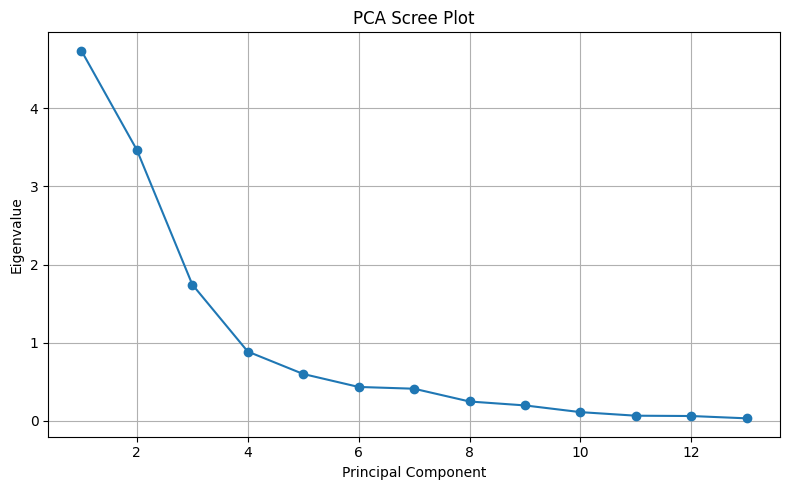

In [49]:
print("\n" + "=" * 80)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 80)

pca = PCA()
pca.fit(analysis_scaled)

explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

pca_variance_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Eigenvalue": explained_variance,
    "Explained_Variance_Ratio": explained_variance_ratio,
    "Cumulative_Variance_Ratio": cumulative_variance_ratio
})

print("\nPCA variance table:")
print(pca_variance_table.round(4))

# Suggested number of PCs using Kaiser criterion
n_components_kaiser = sum(explained_variance > 1)
print(f"\nSuggested number of principal components (Eigenvalue > 1): {n_components_kaiser}")

# Loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=analysis_scaled.columns,
    columns=[f"PC{i+1}" for i in range(len(analysis_scaled.columns))]
)

print("\nPCA loadings:")
print(pca_loadings.round(4))

# PCA scores
pca_scores = pca.transform(analysis_scaled)
pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=[f"PC{i+1}_Score" for i in range(pca_scores.shape[1])]
)

print("\nPCA scores (first 5 rows):")
print(pca_scores_df.head())

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
#plt.axhline(y=1, linestyle="--")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_scree_plot.png", dpi=300)
plt.show()



Loading Matrix for First 8 Principal Components:
               PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8
nat_demand -0.1613  0.7846 -0.0023  0.1815 -0.1343 -0.1130  0.5421 -0.0075
T2M_toc    -0.2027  0.9306 -0.1018  0.0716 -0.0325 -0.0495 -0.1869 -0.0153
QV2M_toc    0.8302  0.1262 -0.1698  0.3674  0.2500  0.0223 -0.0403  0.0075
TQL_toc     0.5147  0.3248  0.3804 -0.3386  0.5795 -0.0808  0.0948 -0.1155
W2M_toc    -0.7776 -0.0771  0.2061  0.2729  0.2031  0.4192  0.0643  0.0933
T2M_san    -0.3972  0.8789 -0.1075 -0.0470  0.0094  0.0264 -0.1672 -0.0208
QV2M_san    0.8845  0.1770 -0.0147  0.3608  0.0279 -0.0011 -0.0206  0.0874
TQL_san     0.6093  0.3716  0.4922 -0.2897 -0.1166  0.0553 -0.0106  0.3813
W2M_san    -0.6591  0.0766  0.5847  0.2984  0.1353  0.0544 -0.0286  0.0029
T2M_dav    -0.3591  0.8969 -0.0914 -0.0389  0.0100 -0.0006 -0.1426 -0.0201
QV2M_dav    0.8809  0.1553 -0.0150  0.3581 -0.0839  0.0465 -0.0727 -0.0580
TQL_dav     0.6360  0.2244  0.4945 -0.1746 -0.2952 

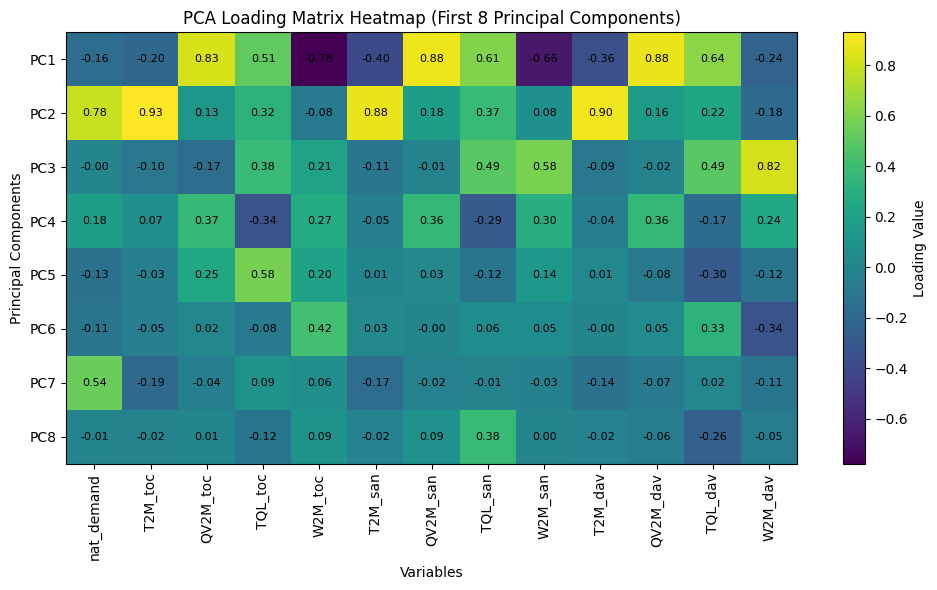

In [39]:
# PCA with first 6 components
pca = PCA(n_components=8)
pca.fit(analysis_scaled)

# True PCA loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loading_matrix = pd.DataFrame(
    loadings,
    index=analysis_scaled.columns,
    columns=[f"PC{i+1}" for i in range(8)]
)

print("Loading Matrix for First 8 Principal Components:")
print(loading_matrix.round(4))

# Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(loading_matrix.T, aspect="auto")
plt.colorbar(label="Loading Value")

plt.xticks(range(len(loading_matrix.index)), loading_matrix.index, rotation=90)
plt.yticks(range(len(loading_matrix.columns)), loading_matrix.columns)

plt.title("PCA Loading Matrix Heatmap (First 8 Principal Components)")
plt.xlabel("Variables")
plt.ylabel("Principal Components")

# Show values inside cells
for i in range(loading_matrix.shape[1]):
    for j in range(loading_matrix.shape[0]):
        plt.text(
            j, i,
            f"{loading_matrix.iloc[j, i]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("pca_loading_heatmap_first8.png", dpi=300)
plt.show()

### 12. FACTOR ANALYSIS (FA)


FACTOR ANALYSIS (FA)

Bartlett's Test Chi-Square: 574975.1336
Bartlett's Test p-value   : 0.0000000000
Overall KMO               : 0.7776

KMO per variable:
      Variable     KMO
0   nat_demand  0.9582
1      T2M_toc  0.8246
2     QV2M_toc  0.8317
3      TQL_toc  0.7458
4      W2M_toc  0.8115
5      T2M_san  0.7364
6     QV2M_san  0.7622
7      TQL_san  0.7456
8      W2M_san  0.6971
9      T2M_dav  0.8226
10    QV2M_dav  0.7759
11     TQL_dav  0.7646
12     W2M_dav  0.5880

FA eigenvalues:
    Factor_Number  Eigenvalue
0               1      4.7373
1               2      3.4677
2               3      1.7447
3               4      0.8870
4               5      0.6001
5               6      0.4341
6               7      0.4114
7               8      0.2478
8               9      0.1977
9              10      0.1117
10             11      0.0661
11             12      0.0619
12             13      0.0323

Suggested number of factors (Eigenvalue > 1): 3

Factor loadings:
            Fact

C:\Users\Nithmi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Nithmi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Nithmi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


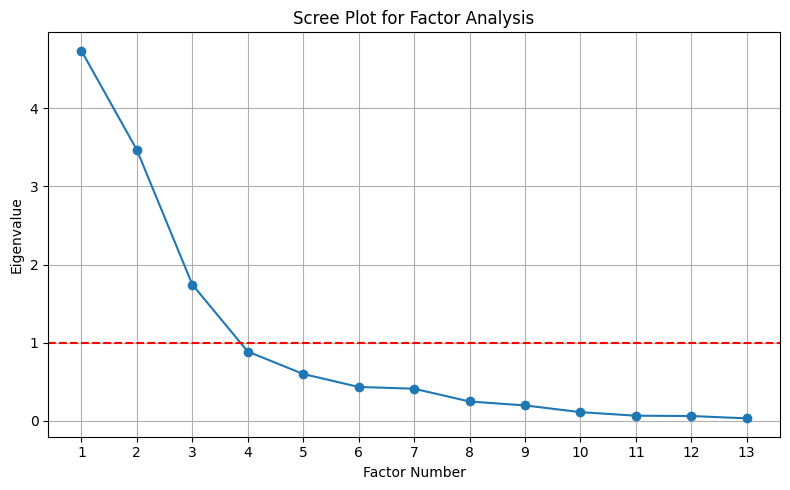

In [20]:
print("\n" + "=" * 80)
print("FACTOR ANALYSIS (FA)")
print("=" * 80)

# Suitability tests
chi_square_value, bartlett_p = calculate_bartlett_sphericity(analysis_scaled)
kmo_all, kmo_model = calculate_kmo(analysis_scaled)

print(f"\nBartlett's Test Chi-Square: {chi_square_value:.4f}")
print(f"Bartlett's Test p-value   : {bartlett_p:.10f}")
print(f"Overall KMO               : {kmo_model:.4f}")

kmo_table = pd.DataFrame({
    "Variable": analysis_scaled.columns,
    "KMO": kmo_all
})

print("\nKMO per variable:")
print(kmo_table.round(4))

# Initial eigenvalues
fa_test = FactorAnalyzer(rotation=None)
fa_test.fit(analysis_scaled)

fa_eigenvalues, _ = fa_test.get_eigenvalues()

fa_eigen_table = pd.DataFrame({
    "Factor_Number": range(1, len(fa_eigenvalues) + 1),
    "Eigenvalue": fa_eigenvalues
})

print("\nFA eigenvalues:")
print(fa_eigen_table.round(4))

n_factors = sum(fa_eigenvalues > 1)
print(f"\nSuggested number of factors (Eigenvalue > 1): {n_factors}")

# Run FA
fa_model = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa_model.fit(analysis_scaled)

fa_loadings = pd.DataFrame(
    fa_model.loadings_,
    index=analysis_scaled.columns,
    columns=[f"Factor_{i+1}" for i in range(n_factors)]
)

print("\nFactor loadings:")
print(fa_loadings.round(4))

fa_communalities = pd.DataFrame({
    "Variable": analysis_scaled.columns,
    "Communality": fa_model.get_communalities()
})

print("\nCommunalities:")
print(fa_communalities.round(4))

variance, prop_var, cum_var = fa_model.get_factor_variance()

fa_variance_table = pd.DataFrame({
    "Factor": [f"Factor_{i+1}" for i in range(n_factors)],
    "SS_Loadings": variance,
    "Proportion_Variance": prop_var,
    "Cumulative_Variance": cum_var
})

print("\nFactor variance explained:")
print(fa_variance_table.round(4))

# Strong loadings only
threshold = 0.40
fa_strong_loadings = fa_loadings.copy()

for col in fa_strong_loadings.columns:
    fa_strong_loadings[col] = fa_strong_loadings[col].apply(
        lambda x: x if abs(x) >= threshold else np.nan
    )

print(f"\nStrong loadings only (|loading| >= {threshold}):")
print(fa_strong_loadings.round(4))

# Factor scores
fa_scores = fa_model.transform(analysis_scaled)
fa_scores_df = pd.DataFrame(
    fa_scores,
    columns=[f"Factor_{i+1}_Score" for i in range(n_factors)]
)

print("\nFactor scores (first 5 rows):")
print(fa_scores_df.head())

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(fa_eigenvalues) + 1), fa_eigenvalues, marker="o")
plt.axhline(y=1,color="red", linestyle="--")
plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot for Factor Analysis")
plt.grid(True)
plt.tight_layout()
plt.xticks(range(1, len(fa_eigenvalues) + 1))
plt.show()

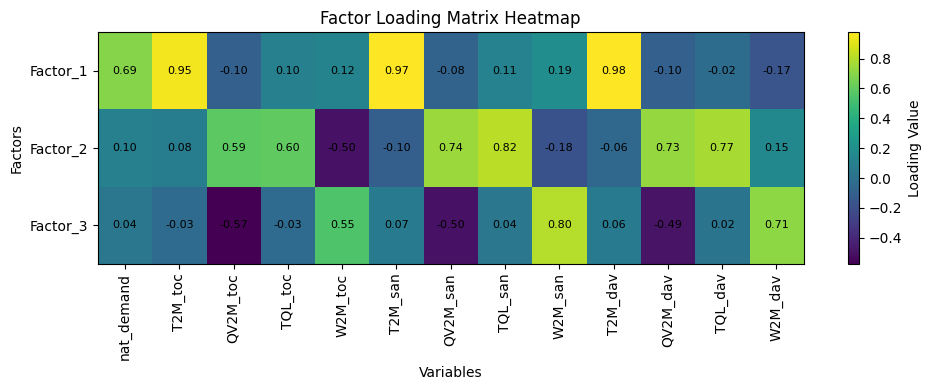

In [40]:
# Factor loading heatmap
plt.figure(figsize=(10, 4))
plt.imshow(fa_loadings.T, aspect="auto")
plt.colorbar(label="Loading Value")

plt.xticks(range(len(fa_loadings.index)), fa_loadings.index, rotation=90)
plt.yticks(range(len(fa_loadings.columns)), fa_loadings.columns)

plt.title("Factor Loading Matrix Heatmap")
plt.xlabel("Variables")
plt.ylabel("Factors")

for i in range(fa_loadings.shape[1]):
    for j in range(fa_loadings.shape[0]):
        plt.text(
            j, i,
            f"{fa_loadings.iloc[j, i]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("fa_loading_heatmap.png", dpi=300)
plt.show()

### 13. PREPARE DATA FOR CCA

In [ ]:
print("\n" + "=" * 80)
print("CANONICAL CORRELATION ANALYSIS (CCA)")
print("=" * 80)

cca_df = df_model[cca_X_vars + cca_Y_vars].copy()

# Missing values
cca_imputer = SimpleImputer(strategy="median")
cca_imputed = pd.DataFrame(
    cca_imputer.fit_transform(cca_df),
    columns=cca_df.columns
)

# Optional outlier capping only for X + nat_demand
# (holiday/school are binary, so leave them unchanged)
cca_processed = cca_imputed.copy()

APPLY_OUTLIER_CAPPING = True

if APPLY_OUTLIER_CAPPING:
    cols_to_cap = cca_X_vars + ["nat_demand"]
    for col in cols_to_cap:
        q1 = cca_processed[col].quantile(0.25)
        q3 = cca_processed[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        cca_processed[col] = cca_processed[col].clip(lower=lower, upper=upper)

X = cca_processed[cca_X_vars]
Y = cca_processed[cca_Y_vars]

# Scale each set separately
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = pd.DataFrame(scaler_x.fit_transform(X), columns=X.columns)
Y_scaled = pd.DataFrame(scaler_y.fit_transform(Y), columns=Y.columns)

print("\nX shape:", X_scaled.shape)
print("Y shape:", Y_scaled.shape)




CANONICAL CORRELATION ANALYSIS (CCA)

X shape: (43775, 12)
Y shape: (43775, 3)
         T2M_toc  QV2M_toc   TQL_toc    W2M_toc    T2M_san  QV2M_san  \
0      25.865259  0.018576  0.016174  21.850546  23.482446  0.017272   
1      25.899255  0.018653  0.016418  22.166944  23.399255  0.017265   
2      25.937280  0.018768  0.015480  22.454911  23.343530  0.017211   
3      25.957544  0.018890  0.016273  22.110481  23.238794  0.017128   
4      25.973840  0.018981  0.017281  21.186089  23.075403  0.017059   
...          ...       ...       ...        ...        ...       ...   
43770  26.635645  0.018421  0.013165  13.184052  25.135645  0.018048   
43771  26.495935  0.018162  0.014713  13.443892  24.769373  0.017781   
43772  26.354456  0.017980  0.013836  13.442195  24.479456  0.017606   
43773  26.166895  0.017965  0.018486  13.420656  24.112207  0.017393   
43774  25.976373  0.018072  0.023315  13.749788  23.663873  0.017156   

        TQL_san    W2M_san    T2M_dav  QV2M_dav   TQL_d

### 14. RUN CCA

In [42]:
n_components = min(X_scaled.shape[1], Y_scaled.shape[1])

cca = CCA(n_components=n_components)
cca.fit(X_scaled, Y_scaled)

X_c, Y_c = cca.transform(X_scaled, Y_scaled)

# Canonical correlations
canonical_corrs = []
for i in range(n_components):
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    canonical_corrs.append(corr)

canonical_corrs = np.array(canonical_corrs)

canonical_corr_table = pd.DataFrame({
    "Canonical_Function": [f"Function_{i+1}" for i in range(n_components)],
    "Canonical_Correlation": canonical_corrs
})

print("\nCanonical correlations:")
print(canonical_corr_table.round(4))





Canonical correlations:
  Canonical_Function  Canonical_Correlation
0         Function_1                 0.7264
1         Function_2                 0.4967
2         Function_3                 0.1126


### 15. CANONICAL LOADINGS

In [25]:
def compute_loadings(original_df, canonical_scores, prefix):
    loadings_dict = {}
    for i in range(canonical_scores.shape[1]):
        loadings_dict[f"{prefix}{i+1}"] = [
            np.corrcoef(original_df.iloc[:, j], canonical_scores[:, i])[0, 1]
            for j in range(original_df.shape[1])
        ]
    return pd.DataFrame(loadings_dict, index=original_df.columns)

X_loadings = compute_loadings(X_scaled, X_c, "U")
Y_loadings = compute_loadings(Y_scaled, Y_c, "V")

print("\nWeather set canonical loadings:")
print(X_loadings.round(4))

print("\nDemand/calendar set canonical loadings:")
print(Y_loadings.round(4))

# Canonical scores
X_scores_df = pd.DataFrame(X_c, columns=[f"U{i+1}" for i in range(n_components)])
Y_scores_df = pd.DataFrame(Y_c, columns=[f"V{i+1}" for i in range(n_components)])



Weather set canonical loadings:
              U1      U2      U3
T2M_toc   0.9655  0.0084  0.0320
QV2M_toc  0.0133  0.7218 -0.1332
TQL_toc   0.1735  0.5646  0.2195
W2M_toc   0.0709 -0.7915  0.4878
T2M_san   0.9300 -0.0707  0.1213
QV2M_san  0.0965  0.6321 -0.2931
TQL_san   0.2416  0.5374  0.1704
W2M_san   0.2180 -0.6346  0.4137
T2M_dav   0.9501 -0.1252 -0.0425
QV2M_dav  0.0601  0.7190 -0.1824
TQL_dav   0.1068  0.4458  0.1359
W2M_dav  -0.1043 -0.3437  0.2186

Demand/calendar set canonical loadings:
                V1      V2      V3
nat_demand  0.9804 -0.0909 -0.1750
holiday    -0.0201 -0.2242  0.9743
school      0.1892  0.9751  0.1153


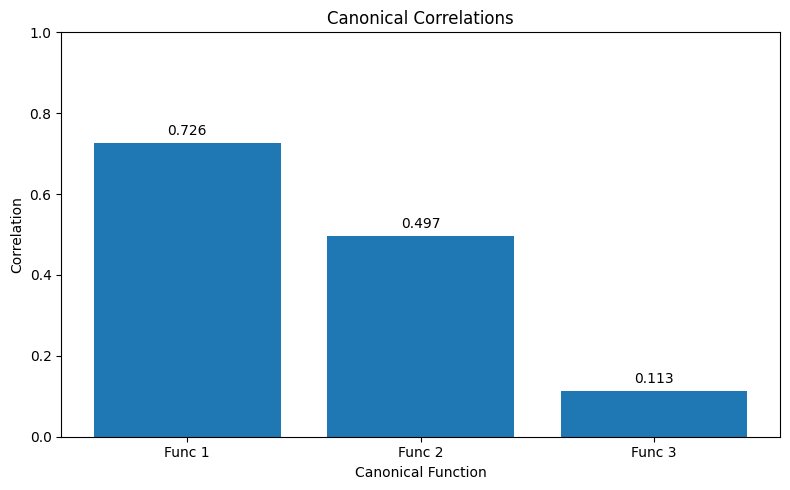

In [43]:
# A. Bar chart of canonical correlations
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(
    [f"Func {i+1}" for i in range(len(canonical_corrs))],
    canonical_corrs
)
plt.title("Canonical Correlations")
plt.xlabel("Canonical Function")
plt.ylabel("Correlation")
plt.ylim(0, 1)

for i, val in enumerate(canonical_corrs):
    plt.text(i, val + 0.02, f"{val:.3f}", ha="center")

plt.tight_layout()
plt.savefig("canonical_corrs.png", dpi=300)
plt.show()

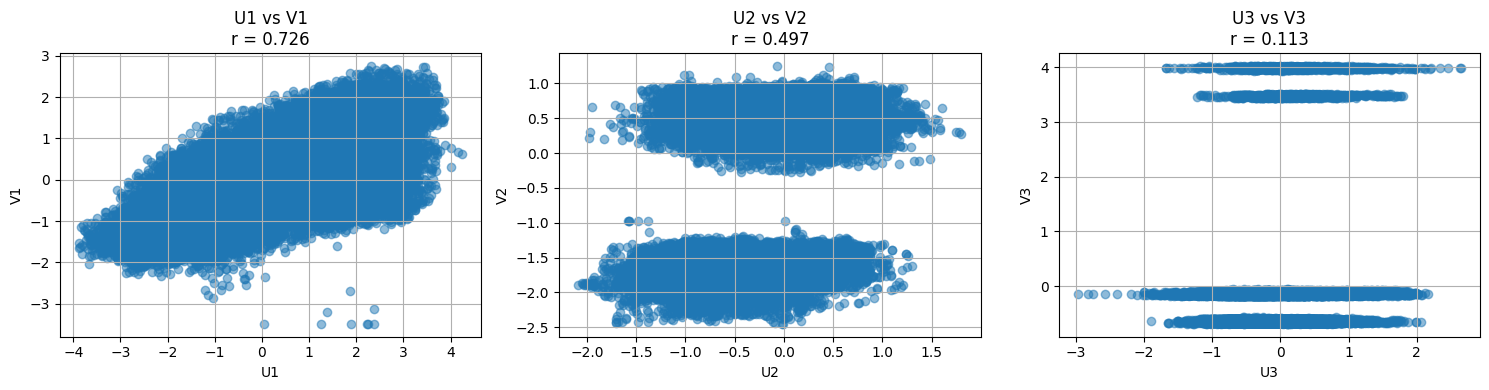

In [48]:
# C. Combined scatter plots in one figure
# -----------------------------
n_components_to_plot = min(3, len(canonical_corrs))
plt.figure(figsize=(15, 4))

for i in range(n_components_to_plot):
    plt.subplot(1, n_components_to_plot, i + 1)
    plt.scatter(X_c[:, i], Y_c[:, i], alpha=0.5)
    plt.title(f"U{i+1} vs V{i+1}\nr = {canonical_corrs[i]:.3f}")
    plt.xlabel(f"U{i+1}")
    plt.ylabel(f"V{i+1}")
    plt.grid(True)

plt.tight_layout()
plt.savefig("relationship.png", dpi=300)
plt.show()

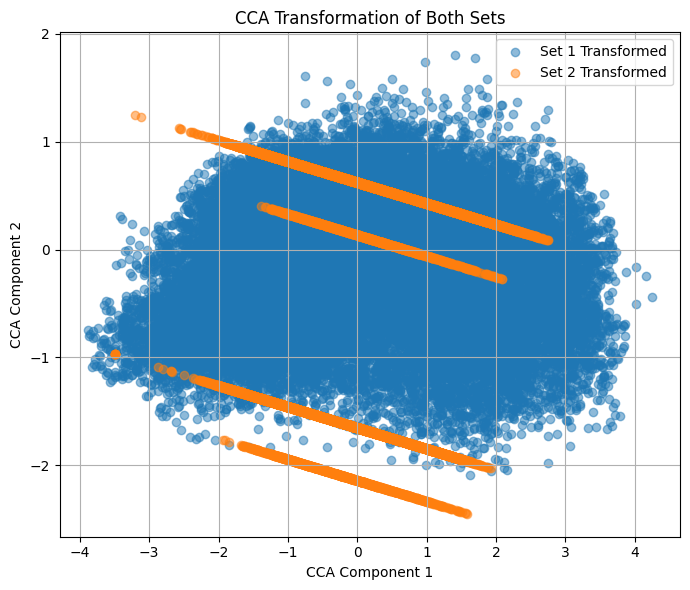

In [ ]:
# ============================================================
# CCA scatter plot like Figure 7 in S19552_DSC4033_mini_project.pdf
# ============================================================

plt.figure(figsize=(7, 6))

# Set 1 transformed (weather set)
plt.scatter(
    X_c[:, 0], X_c[:, 1],
    alpha=0.5,
    label="Set 1 Transformed"
)
# Set 2 transformed (demand/calendar set)
plt.scatter(
    Y_c[:, 0], Y_c[:, 1],
    alpha=0.5,
    label="Set 2 Transformed"
)
plt.title("CCA Transformation of Both Sets")
plt.xlabel("CCA Component 1")
plt.ylabel("CCA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("cca_tranformation.png", dpi=300)
plt.show()

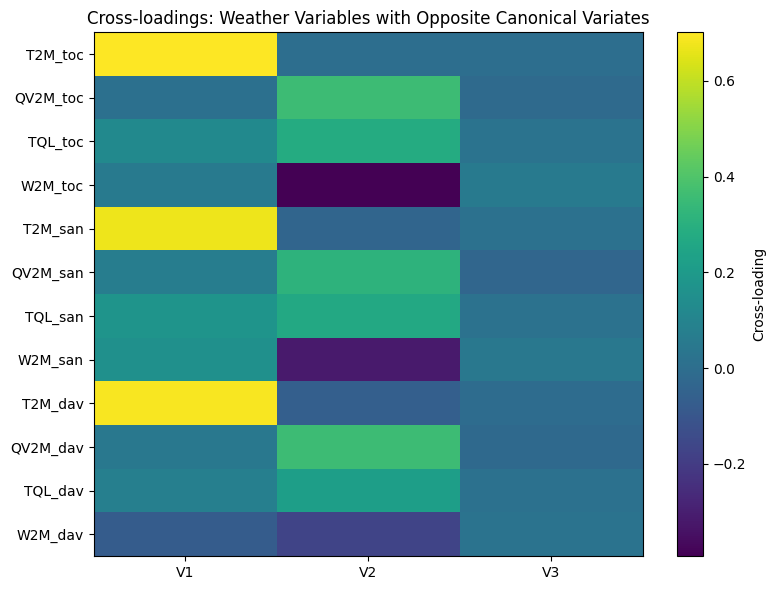

In [29]:
# Cross-loadings heatmap-style plot using matplotlib
# -----------------------------
cross_loadings = pd.DataFrame(index=X_loadings.index)

for i in range(len(canonical_corrs)):
    cross_loadings[f"V{i+1}"] = X_loadings.iloc[:, i] * canonical_corrs[i]

plt.figure(figsize=(8, 6))
plt.imshow(cross_loadings, aspect="auto")
plt.colorbar(label="Cross-loading")
plt.xticks(range(cross_loadings.shape[1]), cross_loadings.columns)
plt.yticks(range(cross_loadings.shape[0]), cross_loadings.index)
plt.title("Cross-loadings: Weather Variables with Opposite Canonical Variates")
plt.tight_layout()

plt.show()